In [13]:
#Importar librerias
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import os
import sys
import numpy as np
import networkx as nx
from networkx.algorithms.approximation import average_clustering
import community.community_louvain as cl
import pandas as pd
import pickle

from utils import *

In [14]:
#Importar datos
filename = 'celegans_connectome.csv'
df_elegans = pd.read_csv(filename)
df_elegans.head()

,Unnamed: 0,Neuron,Target,weight,Neurotransmitter
0,0,ADAL,AIBL,1.0,exc
1,1,ADAL,AIBR,2.0,exc
2,2,ADAL,AVAR,2.0,exc
3,3,ADAL,AVBL,4.0,exc
4,4,ADAL,AVBR,7.0,exc


In [15]:
G_elegans = nx.from_pandas_edgelist(df_elegans, source='Neuron', target='Target', edge_attr=['weight','Neurotransmitter'], create_using=nx.DiGraph())

In [16]:
print('C. elegans')
print(G_elegans)
print('Es dirigido?:',nx.is_directed(G_elegans))
print('Es pesado?:',nx.is_weighted(G_elegans))
print('Es fuertemente conexo?:',nx.is_strongly_connected(G_elegans))
print('Es debilmente conexo?:',nx.is_weakly_connected(G_elegans))
print('')

C. elegans
DiGraph with 299 nodes and 2279 edges
Es dirigido?: True
Es pesado?: True
Es fuertemente conexo?: False
Es debilmente conexo?: False



In [17]:
G_elegansStronglyCC = sorted(nx.strongly_connected_components(G_elegans), key=len, reverse=True)
G_elegansStrongly = G_elegans.subgraph(G_elegansStronglyCC[0])
print('C. elegans componente gigante fuertemente conexo')
print(G_elegansStrongly)
print('Es dirigido?:',nx.is_directed(G_elegansStrongly))
print('Es pesado?:',nx.is_weighted(G_elegansStrongly))
print('Es fuertemente conexo?:',nx.is_strongly_connected(G_elegansStrongly))
print('Es debilmente conexo?:',nx.is_weakly_connected(G_elegansStrongly))

C. elegans componente gigante fuertemente conexo
DiGraph with 237 nodes and 1936 edges
Es dirigido?: True
Es pesado?: True
Es fuertemente conexo?: True
Es debilmente conexo?: True


In [18]:
#G_elegansUndir = nx.DiGraph.to_undirected(G_elegans)

In [19]:
column_names = ['Neuron', 'X', 'Y', 'Z']
positions_df = pd.read_csv('celegans_positions.csv', names=column_names, header=0)

pos_elegans_xy = {row['Neuron']: (row['X'], row['Y']) for _, row in positions_df.iterrows()}
pos_elegans_xz = {row['Neuron']: (row['X'], row['Z']) for _, row in positions_df.iterrows()}
pos_elegans_yz = {row['Neuron']: (row['Y'], row['Z']) for _, row in positions_df.iterrows()}

In [20]:
centrality_bet_complete = nx.betweenness_centrality(G_elegans)
magnification = 5
nodeSize = 30

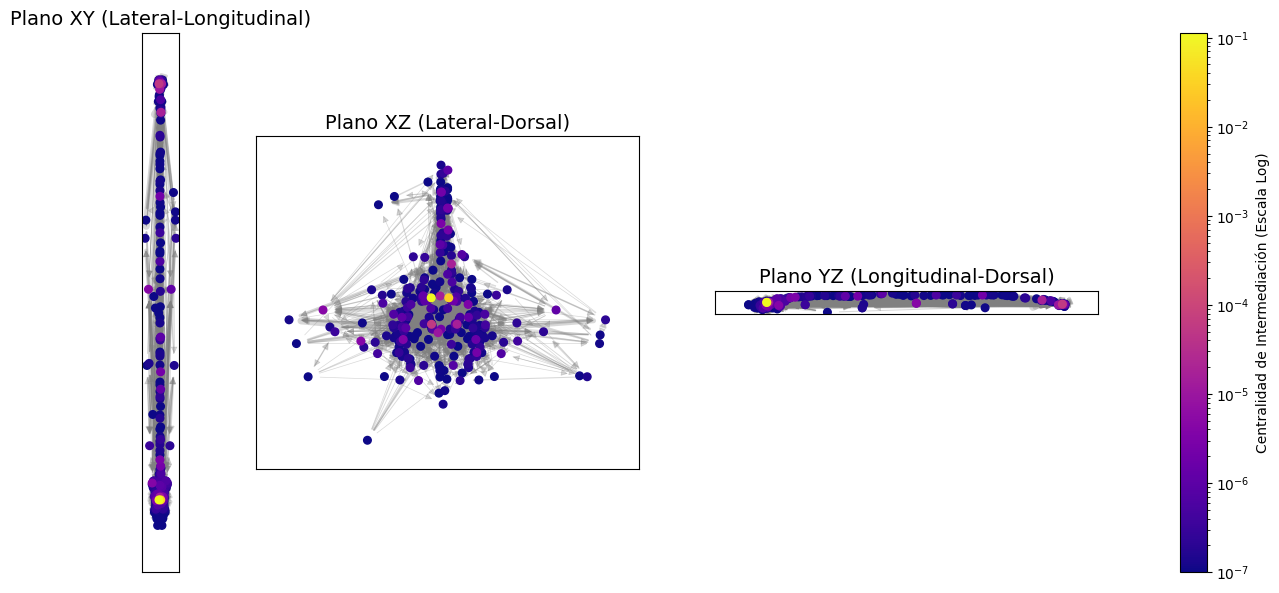

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7)) 

posiciones = [pos_elegans_xy, pos_elegans_xz, pos_elegans_yz]
titulos = ['Plano XY (Lateral-Longitudinal)', 
           'Plano XZ (Lateral-Dorsal)', 
           'Plano YZ (Longitudinal-Dorsal)']

vals = np.array([centrality_bet_complete[n] for n in G_elegans.nodes()])
vals = np.where(vals > 0, vals, 1e-7)

norm = colors.LogNorm(vmin=vals.min(), vmax=vals.max())
vals_norm = norm(vals)

nodos_ordenados = sorted(G_elegans.nodes(), key=lambda n: centrality_bet_complete[n])
colores_ordenados = [centrality_bet_complete[n] if centrality_bet_complete[n] > 0 else 1e-7 
                     for n in nodos_ordenados]

for i, ax in enumerate(axes):
    plt.sca(ax)
    plotWeightedGraph(G_elegans, posiciones[i],magnification)
    nodes = nx.draw_networkx_nodes(
        G_elegans, posiciones[i],
        nodelist=nodos_ordenados,
        node_size=nodeSize,
        node_color=colores_ordenados,
        cmap=plt.cm.plasma,
        ax=ax
    )
    
    ax.set_title(titulos[i], fontsize=14)
    ax.set_aspect('equal')
    ax.axis('on')

sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes, label='Centralidad de Intermediación (Escala Log)')
plt.savefig('plots/C_elegans_comparativa_log.png')
plt.show()

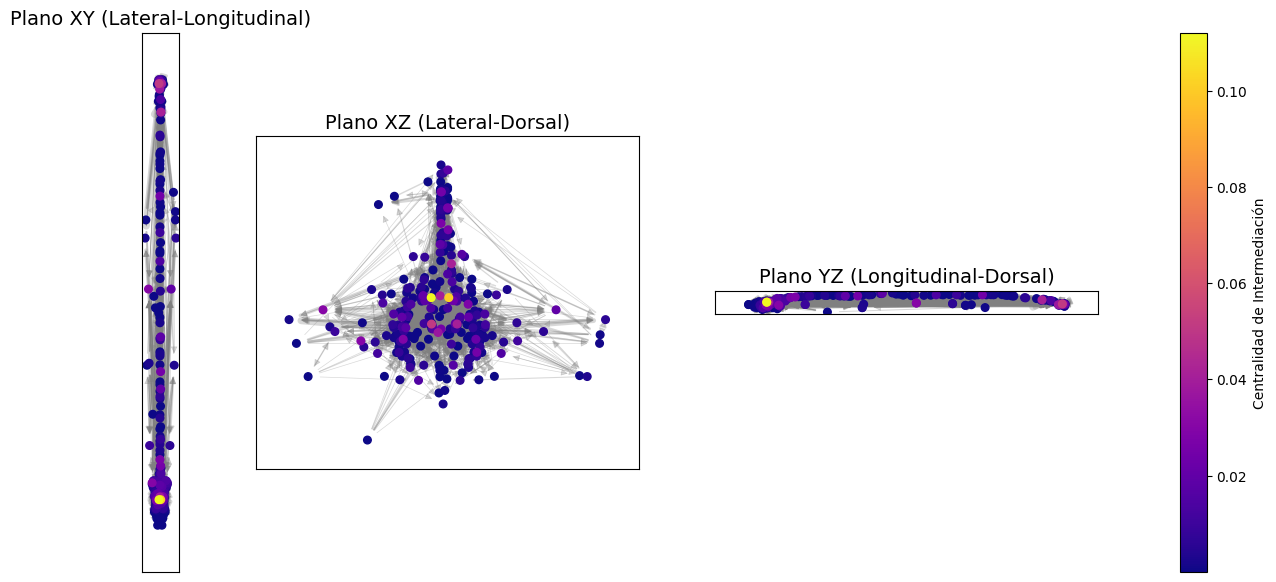

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7)) 

posiciones = [pos_elegans_xy, pos_elegans_xz, pos_elegans_yz]
titulos = ['Plano XY (Lateral-Longitudinal)', 
           'Plano XZ (Lateral-Dorsal)', 
           'Plano YZ (Longitudinal-Dorsal)']

vals = np.array([centrality_bet_complete[n] for n in G_elegans.nodes()])
vals = np.where(vals > 0, vals, 1e-7)

norm = colors.Normalize(vmin=vals.min(), vmax=vals.max())
vals_norm = norm(vals)

nodos_ordenados = sorted(G_elegans.nodes(), key=lambda n: centrality_bet_complete[n])
colores_ordenados = [centrality_bet_complete[n] if centrality_bet_complete[n] > 0 else 1e-7 
                     for n in nodos_ordenados]

for i, ax in enumerate(axes):
    plt.sca(ax)
    plotWeightedGraph(G_elegans, posiciones[i], magnification)
    nodes = nx.draw_networkx_nodes(
        G_elegans, posiciones[i],
        nodelist=nodos_ordenados,
        node_size=nodeSize,
        node_color=colores_ordenados,
        cmap=plt.cm.plasma,
        vmin=vals.min(),
        vmax=vals.max(),
        ax=ax
    )
    
    ax.set_title(titulos[i], fontsize=14)
    ax.set_aspect('equal')
    ax.axis('on')

sm = plt.cm.ScalarMappable(
    cmap=plt.cm.plasma,
    norm=colors.Normalize(vmin=vals.min(), vmax=vals.max())
)
sm.set_array([])
fig.colorbar(sm, ax=axes, label='Centralidad de Intermediación')
plt.savefig('plots/C_elegans_comparativa.png')
plt.show()

In [23]:
print(np.percentile(vals, [0, 25, 50, 75, 90, 99, 100]))

[1.00000000e-07 1.46902316e-04 1.81157074e-03 6.81476668e-03
 1.65327666e-02 4.14182525e-02 1.11984240e-01]


In [24]:
import plotly.graph_objects as go

# 1. Creamos el diccionario 3D usando tus columnas X, Y, Z
pos_3d = {row['Neuron']: (row['X'], row['Y'], row['Z']) for _, row in positions_df.iterrows()}

# 2. Calculamos la centralidad (asegurarnos de que sea sobre G_elegans completo)
centrality_bet = nx.betweenness_centrality(G_elegans)

# 3. Extraer coordenadas para las aristas (Edges)
edge_x, edge_y, edge_z = [], [], []
for edge in G_elegans.edges():
    x0, y0, z0 = pos_3d[edge[0]]
    x1, y1, z1 = pos_3d[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])
    edge_z.extend([z0, z1, None])

edge_trace = go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    line=dict(width=1, color='#888'),
    hoverinfo='none',
    mode='lines',
    opacity=0.3
)

# 4. Extraer coordenadas y atributos para los nodos
node_x, node_y, node_z = [], [], []
node_color, node_size, node_text = [], [], []

for node in G_elegans.nodes():
    x, y, z = pos_3d[node]
    node_x.append(x)
    node_y.append(y)
    node_z.append(z)
    
    val = centrality_bet[node]
    node_color.append(val)
    # Exageramos el tamaño: multiplicamos por 1000 y sumamos un mínimo
    node_size.append(val * 1000 + 3) 
    node_text.append(f'Neurona: {node}<br>Betweenness: {val:.4f}')

node_trace = go.Scatter3d(
    x=node_x, y=node_y, z=node_z,
    mode='markers',
    hoverinfo='text',
    text=node_text,
    marker=dict(
        showscale=True,
        colorscale='Viridis',
        color=node_color,
        size=node_size,
        colorbar=dict(thickness=15, title='Betweenness'),
        line_width=0.5
    )
)

# 5. Definir el layout y mostrar
fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title='Conectoma 3D de C. elegans - Importancia Estratégica',
                scene=dict(
                    xaxis_title='Lateral (X)',
                    yaxis_title='Longitudinal (Y)',
                    zaxis_title='Dorso-ventral (Z)',
                    # Esto mantiene la proporción real del gusano
                    aspectmode='data' 
                ),
                margin=dict(b=0, l=0, r=0, t=40)
             ))

fig.show()